# Weight Initialization & Batch Normalization

**Assignment Coverage:** Part 1 (e-f)

**Techniques Demonstrated:**
- Weight Initialization: Zero, Random, Xavier/Glorot, He, LeCun, Orthogonal
- Batch Normalization and its variants
- When to use which initialization based on activation function

**Frameworks:** TensorFlow/Keras and PyTorch

**Dataset:** Fashion MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0
X_train_flat, X_test_flat = X_train.reshape(-1, 784), X_test.reshape(-1, 784)
X_val, y_val = X_train_flat[:5000], y_train[:5000]
X_train_flat, y_train = X_train_flat[5000:], y_train[5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


---
## 1. Weight Initialization Techniques

**Guidelines:**
- **Sigmoid/Tanh**: Use Xavier/Glorot
- **ReLU/variants**: Use He initialization
- **SELU**: Use LeCun initialization
- **RNNs**: Consider Orthogonal

### TensorFlow Implementation

In [3]:
initializers = {
    'Zeros': keras.initializers.Zeros(),
    'RandomNormal': keras.initializers.RandomNormal(stddev=0.1),
    'GlorotUniform': keras.initializers.GlorotUniform(),  # Xavier
    'GlorotNormal': keras.initializers.GlorotNormal(),
    'HeNormal': keras.initializers.HeNormal(),
    'HeUniform': keras.initializers.HeUniform(),
    'LecunNormal': keras.initializers.LecunNormal(),
    'Orthogonal': keras.initializers.Orthogonal()
}

def build_model_tf(init):
    return keras.Sequential([
        keras.layers.Dense(256, activation='relu', kernel_initializer=init, input_shape=(784,)),
        keras.layers.Dense(128, activation='relu', kernel_initializer=init),
        keras.layers.Dense(10, activation='softmax')
    ])

print("TensorFlow Initialization Comparison:")
results_tf = {}
for name, init in initializers.items():
    model = build_model_tf(init)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = model.fit(X_train_flat, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val), verbose=0)
    results_tf[name] = h.history
    print(f"{name}: Val Acc = {h.history['val_accuracy'][-1]:.4f}")

TensorFlow Initialization Comparison:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Zeros: Val Acc = 0.0914
RandomNormal: Val Acc = 0.8892
GlorotUniform: Val Acc = 0.8906
GlorotNormal: Val Acc = 0.8938
HeNormal: Val Acc = 0.8946
HeUniform: Val Acc = 0.8956
LecunNormal: Val Acc = 0.8904
Orthogonal: Val Acc = 0.8988


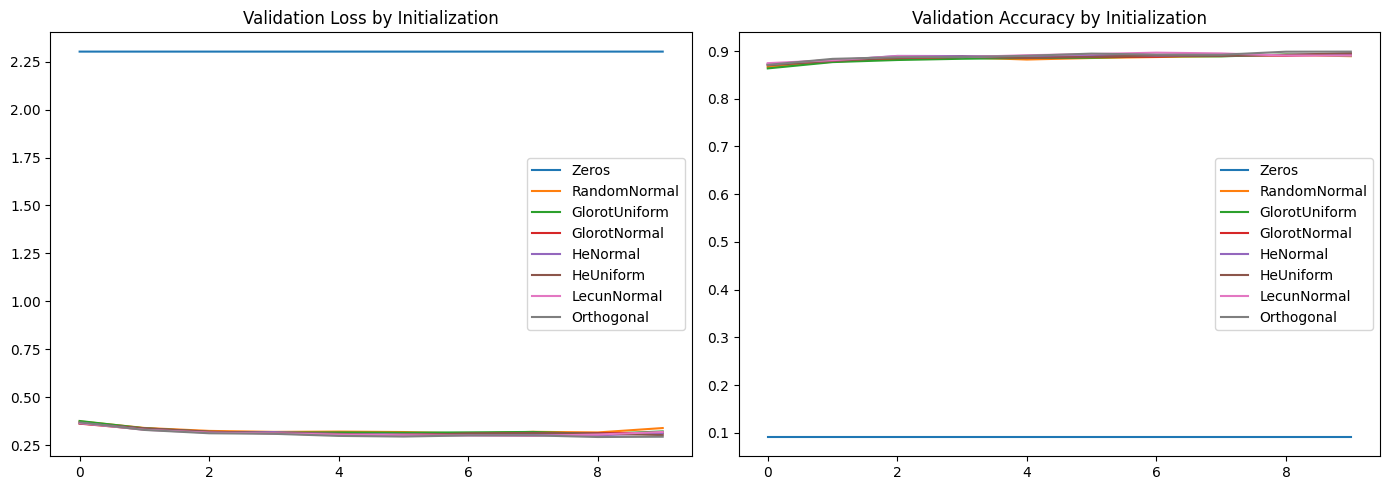

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in results_tf.items():
    axes[0].plot(hist['val_loss'], label=name)
    axes[1].plot(hist['val_accuracy'], label=name)
axes[0].set_title('Validation Loss by Initialization')
axes[1].set_title('Validation Accuracy by Initialization')
axes[0].legend(); axes[1].legend()
plt.tight_layout(); plt.show()

### PyTorch Implementation

In [5]:
X_train_pt = torch.FloatTensor(X_train_flat)
y_train_pt = torch.LongTensor(y_train)
X_val_pt = torch.FloatTensor(X_val)
y_val_pt = torch.LongTensor(y_val)
train_loader = DataLoader(TensorDataset(X_train_pt, y_train_pt), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_pt, y_val_pt), batch_size=64)

/tmp/ipykernel_2347/104232343.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  y_train_pt = torch.LongTensor(y_train)


In [6]:
class InitNet(nn.Module):
    def __init__(self, init_fn):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        # Apply initialization
        for layer in [self.fc1, self.fc2, self.fc3]:
            init_fn(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

def train_pt(model, epochs=10):
    opt, crit = optim.Adam(model.parameters()), nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        for X, y in train_loader:
            opt.zero_grad(); crit(model(X), y).backward(); opt.step()
    model.eval()
    return sum((model(X).argmax(1)==y).sum().item() for X,y in val_loader) / len(val_loader.dataset)

pt_inits = {
    'Zeros': lambda w: nn.init.zeros_(w),
    'RandomNormal': lambda w: nn.init.normal_(w, std=0.1),
    'XavierUniform': lambda w: nn.init.xavier_uniform_(w),
    'XavierNormal': lambda w: nn.init.xavier_normal_(w),
    'KaimingUniform': lambda w: nn.init.kaiming_uniform_(w, nonlinearity='relu'),  # He
    'KaimingNormal': lambda w: nn.init.kaiming_normal_(w, nonlinearity='relu'),
    'Orthogonal': lambda w: nn.init.orthogonal_(w)
}

print("\nPyTorch Initialization Comparison:")
for name, init_fn in pt_inits.items():
    acc = train_pt(InitNet(init_fn))
    print(f"{name}: Val Acc = {acc:.4f}")


PyTorch Initialization Comparison:
Zeros: Val Acc = 0.0914
RandomNormal: Val Acc = 0.8942
XavierUniform: Val Acc = 0.8958
XavierNormal: Val Acc = 0.8932
KaimingUniform: Val Acc = 0.8946
KaimingNormal: Val Acc = 0.8972
Orthogonal: Val Acc = 0.8952


---
## 2. Activation-Initialization Pairing

Demonstrating correct pairing of activations with their optimal initializers.

In [7]:
# Optimal pairings comparison
pairings = [
    ('tanh', 'glorot_uniform'),    # Correct: Xavier for tanh
    ('tanh', 'he_normal'),          # Suboptimal
    ('relu', 'he_normal'),          # Correct: He for ReLU
    ('relu', 'glorot_uniform'),     # Suboptimal
    ('selu', 'lecun_normal'),       # Correct: LeCun for SELU
]

print("Activation-Initialization Pairing Test:")
for act, init in pairings:
    model = keras.Sequential([
        keras.layers.Dense(256, activation=act, kernel_initializer=init, input_shape=(784,)),
        keras.layers.Dense(128, activation=act, kernel_initializer=init),
        keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = model.fit(X_train_flat, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val), verbose=0)
    print(f"{act} + {init}: Val Acc = {h.history['val_accuracy'][-1]:.4f}")

Activation-Initialization Pairing Test:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


tanh + glorot_uniform: Val Acc = 0.8916
tanh + he_normal: Val Acc = 0.8876
relu + he_normal: Val Acc = 0.8906
relu + glorot_uniform: Val Acc = 0.8952
selu + lecun_normal: Val Acc = 0.8852


---
## 3. Batch Normalization
### TensorFlow Implementation

In [8]:
# Model without BatchNorm
model_no_bn = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(784,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Model with BatchNorm (applied before activation)
model_bn = keras.Sequential([
    keras.layers.Dense(256, input_shape=(784,)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.Dense(128),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.Dense(10, activation='softmax')
])

print("A/B Test: With vs Without BatchNorm")
for name, model in [('No BN', model_no_bn), ('With BN', model_bn)]:
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = model.fit(X_train_flat, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val), verbose=0)
    print(f"{name}: Val Acc = {h.history['val_accuracy'][-1]:.4f}")

A/B Test: With vs Without BatchNorm
No BN: Val Acc = 0.8958
With BN: Val Acc = 0.8456


### PyTorch Implementation

In [9]:
class NetWithBN(nn.Module):
    def __init__(self, use_bn=True):
        super().__init__()
        self.use_bn = use_bn
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        if use_bn:
            self.bn1 = nn.BatchNorm1d(256)
            self.bn2 = nn.BatchNorm1d(128)

    def forward(self, x):
        x = self.fc1(x)
        if self.use_bn: x = self.bn1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        if self.use_bn: x = self.bn2(x)
        x = torch.relu(x)
        return self.fc3(x)

print("\nPyTorch BatchNorm Comparison:")
for name, use_bn in [('No BN', False), ('With BN', True)]:
    acc = train_pt(NetWithBN(use_bn))
    print(f"{name}: Val Acc = {acc:.4f}")


PyTorch BatchNorm Comparison:
No BN: Val Acc = 0.8886
With BN: Val Acc = 0.8912


### BatchNorm Variants

In [10]:
# Layer Normalization - useful for RNNs and Transformers
model_ln = keras.Sequential([
    keras.layers.Dense(256, input_shape=(784,)),
    keras.layers.LayerNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.Dense(128),
    keras.layers.LayerNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.Dense(10, activation='softmax')
])

model_ln.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h = model_ln.fit(X_train_flat, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val), verbose=0)
print(f"LayerNorm: Val Acc = {h.history['val_accuracy'][-1]:.4f}")

LayerNorm: Val Acc = 0.8940


In [11]:
# PyTorch variants
class NormVariants(nn.Module):
    def __init__(self, norm_type='batch'):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        if norm_type == 'batch':
            self.norm1, self.norm2 = nn.BatchNorm1d(256), nn.BatchNorm1d(128)
        elif norm_type == 'layer':
            self.norm1, self.norm2 = nn.LayerNorm(256), nn.LayerNorm(128)
        else:
            self.norm1 = self.norm2 = nn.Identity()

    def forward(self, x):
        x = torch.relu(self.norm1(self.fc1(x)))
        x = torch.relu(self.norm2(self.fc2(x)))
        return self.fc3(x)

print("\nPyTorch Normalization Variants:")
for norm in ['none', 'batch', 'layer']:
    acc = train_pt(NormVariants(norm))
    print(f"{norm.capitalize()}Norm: Val Acc = {acc:.4f}")


PyTorch Normalization Variants:
NoneNorm: Val Acc = 0.8928
BatchNorm: Val Acc = 0.8924
LayerNorm: Val Acc = 0.8836


---
## Summary

| Activation | Recommended Initialization |
|------------|---------------------------|
| Sigmoid/Tanh | Xavier/Glorot |
| ReLU/Leaky ReLU | He (Kaiming) |
| SELU | LeCun |
| RNN/LSTM | Orthogonal |

| Normalization | Best Use Case |
|---------------|---------------|
| BatchNorm | CNNs, large batches |
| LayerNorm | RNNs, Transformers |
| GroupNorm | Small batches |